# Análisis bibliométrico y textual — Saki Bigio
**Trabajo grupal 01 · Historia del Pensamiento Económico · Universidad del Pacífico, 2026-02**
Preguntas 3 y 4 · Alejandro Ventura

Este cuaderno reproduce todo el análisis del proyecto a partir de los archivos de `data/`.
Cada figura se guarda en `figs/` y cada número que aparece en los informes sale de alguna celda de aquí.

**Cómo correrlo**

```bash
pip install -r requirements.txt
jupyter lab analisis_bibliometrico.ipynb
```

**Insumos que espera en `data/`**

| Archivo | Qué es | Origen |
|---|---|---|
| `corpus.csv` | 47 documentos con año, género, venue, coautores, JEL, familia autodeclarada | elaboración propia sobre los PDFs + CV |
| `frontmatter.json` | título, abstract, keywords y JEL por documento | extracción con `pymupdf` |
| `referencias_parseadas.json` | 1 194 entradas bibliográficas de 31 documentos | `parse_refs.py` sobre las secciones de referencias |
| `s2/s2_papers.json` · `s2/s2_citations.json` | 61 trabajos y 875 trabajos citantes | Semantic Scholar Graph API, autor `118979062` |
| `openalex/openalex_02_works.json` | 89 registros con FWCI y percentil normalizado | OpenAlex, autor `A5024020324` |
| `anclas_doctrinales.json` | presencia de 32 anclas doctrinales por documento | búsqueda sobre 3,38 M de caracteres |


## 0 · Preparación

In [1]:
import json, re, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

warnings.filterwarnings('ignore')
DATA = Path('data'); FIGS = Path('figs'); FIGS.mkdir(exist_ok=True)

# paleta del proyecto: práctica (ocre), teoría (verde azulado), medición (oxblood)
PRACTICA, TEORIA, GAP = '#A85907', '#1A5B69', '#8B2F3A'
TINTA, SUAVE, TENUE, REGLA = '#1B1713', '#5E564B', '#8B8172', '#DCD5C7'
SERIE = [TEORIA, PRACTICA, GAP, '#4A7B5C', '#6E5B8B', '#8B7355']

mpl.rcParams.update({
    'figure.dpi': 130, 'savefig.dpi': 200, 'savefig.bbox': 'tight',
    'font.family': 'DejaVu Sans', 'font.size': 9,
    'axes.edgecolor': REGLA, 'axes.labelcolor': SUAVE, 'axes.titlesize': 11,
    'axes.titleweight': 'bold', 'axes.titlecolor': TINTA, 'axes.titlelocation': 'left',
    'axes.spines.top': False, 'axes.spines.right': False,
    'xtick.color': TENUE, 'ytick.color': TENUE, 'text.color': TINTA,
    'axes.grid': True, 'grid.color': '#EDE8DC', 'grid.linewidth': .7,
    'figure.facecolor': 'white', 'axes.facecolor': 'white', 'legend.frameon': False,
})

def guardar(fig, nombre):
    fig.savefig(FIGS / f'{nombre}.png', facecolor='white')
    print(f'→ figs/{nombre}.png')


## 1 · El corpus

La cronología usa `anio_primera_version`, no solo el año de revista. Las trece fechas de los artículos publicados tienen una tabla de procedencia en `data/first_version_sources.csv`: siete se apoyan en evidencia documental o en un linaje verificable de OpenAlex y seis quedan con confianza media. Por ello, el rezago de publicación se interpreta como una estimación documentada, no como una medición sin error.

La periodización 2006–2013 / 2014–2019 / 2020–2026 es el corte principal, pero las lecturas temáticas se someten también a una prueba de sensibilidad moviendo el primer corte a 2012.

In [2]:
corpus = pd.read_csv(DATA/'corpus.csv')
first_sources = pd.read_csv(DATA/'first_version_sources.csv')
corpus['a1'] = corpus['anio_primera_version'].fillna(corpus['anio']).astype(int)

def periodo(y):
    return 'I · 2006–2013' if y <= 2013 else ('II · 2014–2019' if y <= 2019 else 'III · 2020–2026')
corpus['periodo'] = corpus['a1'].map(periodo)

GENEROS = {'published':'Publicado','wp':'Working paper / R&R','discussion':'Discussion (slides)',
           'comment':'Comentario publicado','pre_phd':'Pre-PhD (BCRP)','publicado_es':'Capítulo en castellano',
           'vision':'Research vision','policy':'Carta de política','divulgacion':'Divulgación'}
corpus['genero_es'] = corpus['genero'].map(GENEROS).fillna(corpus['genero'])

assert (corpus['a1'] <= corpus['anio']).all(), 'hay primeras versiones posteriores a la publicación'
assert set(first_sources.id) == set(corpus.loc[corpus.genero == 'published', 'id'])
print(f"{len(corpus)} documentos · {corpus['paginas'].sum():,} páginas · {corpus['chars'].sum():,} caracteres")
print(f"rango {corpus['a1'].min()}–{corpus['a1'].max()} · fechas publicadas: "
      f"{(first_sources.confianza == 'alta').sum()} de confianza alta y "
      f"{(first_sources.confianza == 'media').sum()} de confianza media")
display(corpus.groupby(['periodo','genero_es']).size().unstack(fill_value=0))


48 documentos · 1,995 páginas · 3,416,048 caracteres
rango 2006–2026 · fechas publicadas: 7 de confianza alta y 6 de confianza media


genero_es,Capítulo en castellano,Carta de política,Comentario publicado,Discussion (slides),Divulgación,Pre-PhD (BCRP),Publicado,Research vision,Working paper / R&R
periodo,,,,,,,,,
I · 2006–2013,0,0,0,2,0,2,5,0,0
II · 2014–2019,0,0,2,7,0,0,6,0,2
III · 2020–2026,1,1,1,6,1,0,2,1,9


→ figs/01_corpus.png


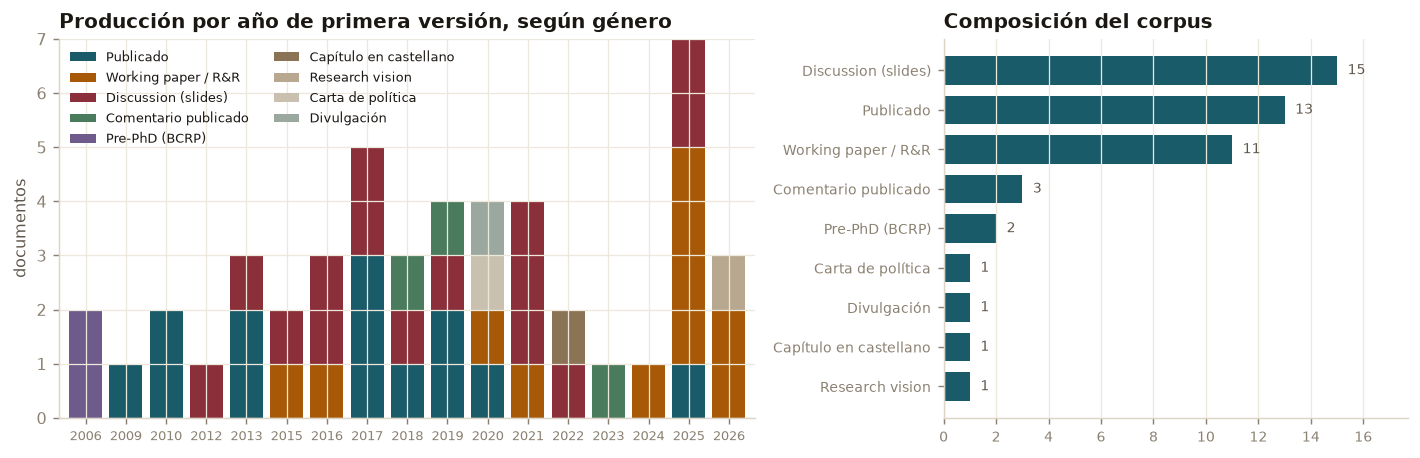

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6), gridspec_kw={'width_ratios':[1.5,1]})

piv = corpus.pivot_table(index='a1', columns='genero_es', aggfunc='size', fill_value=0)
orden = [g for g in ['Publicado','Working paper / R&R','Discussion (slides)','Comentario publicado',
                     'Pre-PhD (BCRP)','Capítulo en castellano','Research vision','Carta de política','Divulgación']
         if g in piv.columns]
piv[orden].plot.bar(stacked=True, ax=ax1, color=SERIE+['#B8A88F','#C9C0B0','#9AA8A0'], width=.82, legend=False)
ax1.set_title('Producción por año de primera versión, según género')
ax1.set_xlabel(''); ax1.set_ylabel('documentos')
ax1.legend(fontsize=7, ncol=2, loc='upper left')
ax1.tick_params(axis='x', rotation=0, labelsize=7)

cg = corpus['genero_es'].value_counts()
ax2.barh(cg.index[::-1], cg.values[::-1], color=TEORIA, height=.72)
for i, v in enumerate(cg.values[::-1]):
    ax2.text(v+.4, i, str(v), va='center', fontsize=8, color=SUAVE)
ax2.set_title('Composición del corpus'); ax2.set_xlim(0, cg.max()*1.18)
ax2.grid(axis='y', visible=False); ax2.tick_params(labelsize=8)
plt.tight_layout(); guardar(fig, '01_corpus'); plt.show()


## 2 · Desempeño: impacto y su distribución

OpenAlex indexa artículos, preprints, informes y repositorios como registros separados aunque pertenezcan a una misma obra intelectual. El archivo bruto conserva los 89 registros solicitados; el archivo canónico excluye solo 12 datasets y 2 softwares y agrupa 75 registros de investigación en 34 obras. **Las citas de versiones no se suman**: para cada obra se conserva una versión representativa y el máximo por versión como indicador conservador.

El FWCI (*field-weighted citation impact*) normaliza por campo y año. Se muestra únicamente para la versión representativa y junto al percentil, porque los valores extremos pueden depender de bases pequeñas.

In [4]:
ox = json.load(open(DATA/'openalex'/'openalex_02_works.json', encoding='utf-8'))
W_raw = ox['results'] if isinstance(ox, dict) else ox
W = [w for w in W_raw if w.get('type') not in ('dataset','software')]
canonical = json.load(open(DATA/'openalex'/'openalex_02_works_canonical.json', encoding='utf-8'))
CW = canonical['works']

def short_id(value): return str(value or '').rsplit('/', 1)[-1]
def num(x):
    try: return float(x)
    except (TypeError, ValueError): return np.nan

W_by_id = {short_id(w.get('id')): w for w in W}
representatives = [W_by_id[c['representative_openalex_id']] for c in CW
                   if c['representative_openalex_id'] in W_by_id]
ow = pd.DataFrame([{
    'id': short_id(w.get('id')), 'titulo': w.get('display_name'),
    'anio': num(w.get('publication_year')), 'tipo': w.get('type'),
    'citas': num(w.get('cited_by_count')), 'fwci': num(w.get('fwci')),
    'pct': (w.get('citation_normalized_percentile') or {}).get('value')
           if isinstance(w.get('citation_normalized_percentile'), dict) else np.nan,
    'fuente': ((w.get('primary_location') or {}).get('source') or {}).get('display_name')
              if isinstance(w.get('primary_location'), dict) else None,
} for w in representatives])

print(f"{canonical['meta']['raw_records']} registros brutos → "
      f"{canonical['meta']['research_records']} registros de investigación → "
      f"{canonical['meta']['canonical_works']} obras canónicas")
print('Regla: no sumar cited_by_count entre versiones; el reparto formal/gris no es identificable sin deduplicar citantes.')

top = ow.dropna(subset=['fwci']).nlargest(10, 'fwci')
display(top[['titulo','anio','fuente','citas','fwci','pct']].style.format(
    {'anio':'{:.0f}','citas':'{:.0f}','fwci':'{:.1f}','pct':'{:.3f}'}))


89 registros brutos → 75 registros de investigación → 34 obras canónicas
Regla: no sumar cited_by_count entre versiones; el reparto formal/gris no es identificable sin deduplicar citantes.


,titulo,anio,fuente,citas,fwci,pct
1,Endogenous Liquidity and the Business Cycle,2015,American Economic Review,190,61.6,0.998
0,Distortions in Production Networks*,2020,The Quarterly Journal of Economics,223,42.8,0.999
4,"A Monetary and Fiscal History of Latin America, 1960–2017",2020,University of Minnesota Press eBooks,59,6.3,0.969
3,Optimal self-employment income tax enforcement,2010,Journal of Public Economics,87,5.2,0.952
8,"Liquidity shocks, business cycles and asset prices",2017,European Economic Review,20,2.8,0.907
12,Un modelo semiestructural de proyección para la economía peruana,2009,RePEc: Research Papers in Economics,8,2.8,0.911
13,Liquidity Shocks and the Business Cycle: What next?,2012,nan,7,2.0,0.922
11,Debt-Maturity Management with Liquidity Costs,2022,Journal of Political Economy Macroeconomics,13,1.7,0.849
7,Financial Risk Capacity,2021,American Economic Journal Macroeconomics,22,1.2,0.792
16,Learning under fear of floating,2010,Journal of Economic Dynamics and Control,3,1.1,0.859


→ figs/02_impacto.png


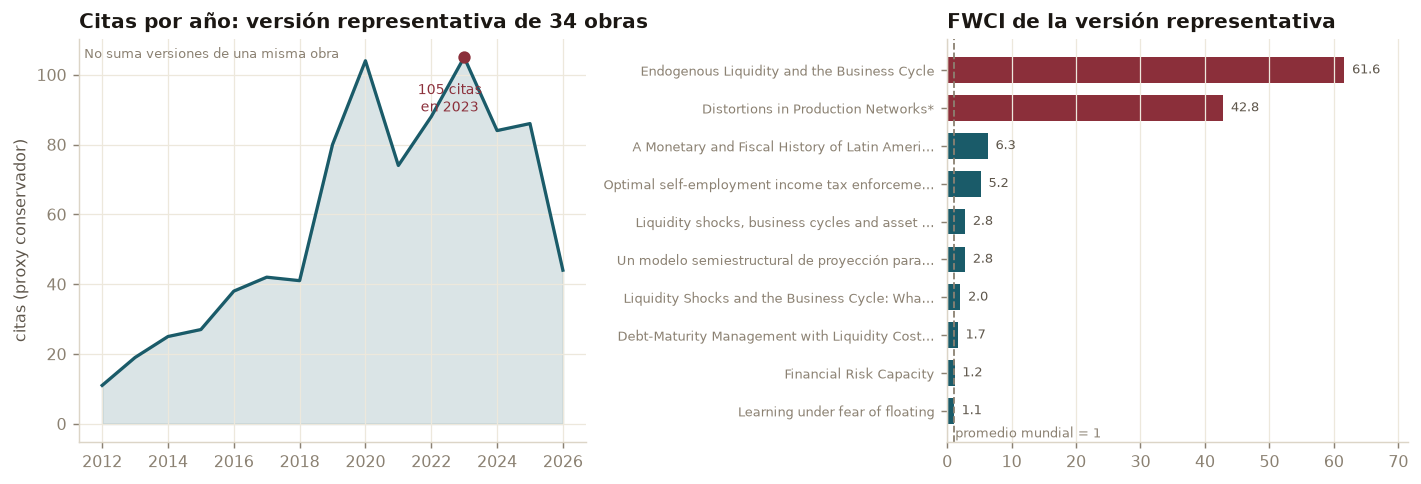

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8), gridspec_kw={'width_ratios':[1.1,1]})

# Serie conservadora: solo la versión representativa de cada obra canónica.
# Evita doble conteo, aunque puede omitir citas asignadas exclusivamente a otra versión.
cby = Counter()
for w in representatives:
    cy = w.get('counts_by_year')
    if isinstance(cy, str):
        try: cy = json.loads(cy)
        except Exception: cy = []
    for c in (cy or []): cby[c['year']] += c.get('cited_by_count', 0)
s = pd.Series(cby).sort_index()
ax1.fill_between(s.index, s.values, color=TEORIA, alpha=.16)
ax1.plot(s.index, s.values, color=TEORIA, lw=1.8)
ax1.scatter([s.idxmax()], [s.max()], color=GAP, zorder=5, s=34)
ax1.annotate(f'{s.max():.0f} citas\nen {s.idxmax()}', (s.idxmax(), s.max()), textcoords='offset points',
             xytext=(-8,-30), fontsize=8, color=GAP, ha='center')
ax1.set_title('Citas por año: versión representativa de 34 obras')
ax1.set_xlabel(''); ax1.set_ylabel('citas (proxy conservador)')
ax1.annotate('No suma versiones de una misma obra', (.01, .98), xycoords='axes fraction',
             va='top', fontsize=7, color=TENUE)

f = ow.dropna(subset=['fwci']).sort_values('fwci')
f = f[f.fwci > 0]
cols = [GAP if v > 10 else TEORIA for v in f.fwci]
ax2.barh(range(len(f)), f.fwci, color=cols, height=.68)
ax2.set_yticks(range(len(f)))
ax2.set_yticklabels([t[:44] + ('…' if len(t) > 44 else '') for t in f.titulo], fontsize=7)
ax2.axvline(1, color=TENUE, ls='--', lw=1)
ax2.text(1.25, -.7, 'promedio mundial = 1', fontsize=7, color=TENUE)
for i, v in enumerate(f.fwci):
    ax2.text(v+1.2, i, f'{v:.1f}', va='center', fontsize=7, color=SUAVE)
ax2.set_title('FWCI de la versión representativa')
ax2.set_xlim(0, f.fwci.max()*1.16); ax2.grid(axis='y', visible=False)
plt.tight_layout(); guardar(fig, '02_impacto'); plt.show()


## 3 · El rezago entre el working paper y la revista

La pregunta 4 exige fechar la primera circulación, no solo la publicación final. En los trece artículos publicados del corpus, la estimación documentada del rezago medio es 4,8 años (mediana 6; máximo 9). Cinco fechas tienen confianza media, por lo que el promedio se presenta con esa reserva y cada caso puede auditarse en `data/first_version_sources.csv`.

rezago medio 4.8 años · mediana 6 · máximo 9


→ figs/03_rezago.png


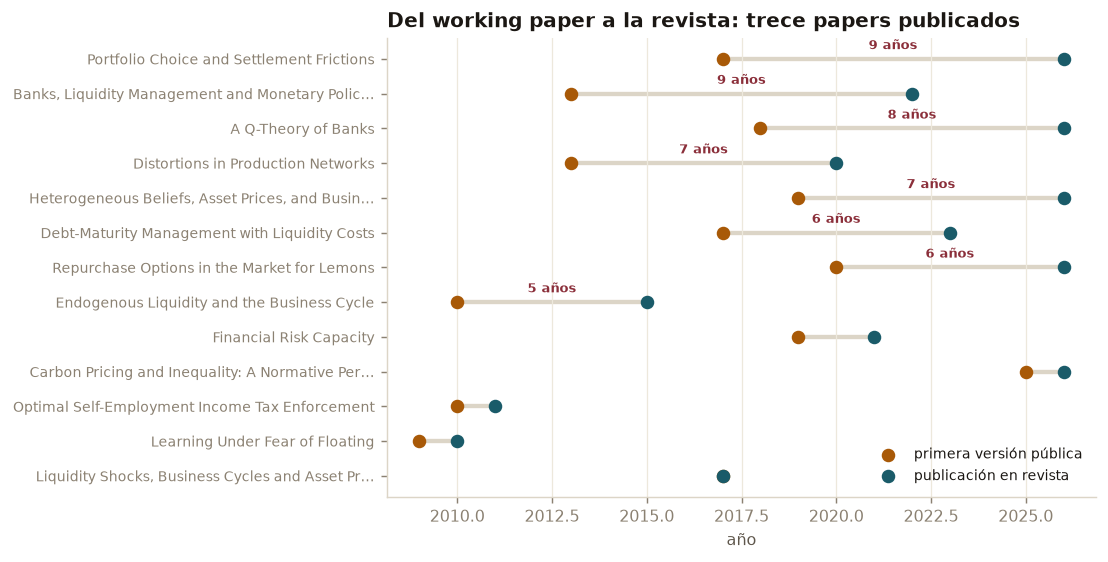

In [6]:
pub = corpus[corpus.genero == 'published'].copy()
pub['rezago'] = pub['anio'] - pub['a1']
pub = pub.sort_values('rezago')
print(f"rezago medio {pub.rezago.mean():.1f} años · mediana {pub.rezago.median():.0f} · máximo {pub.rezago.max()}")

fig, ax = plt.subplots(figsize=(8.6, 4.4))
y = np.arange(len(pub))
ax.hlines(y, pub.a1, pub.anio, color=REGLA, lw=2.4, zorder=1)
ax.scatter(pub.a1, y, color=PRACTICA, s=42, zorder=3, label='primera versión pública')
ax.scatter(pub.anio, y, color=TEORIA, s=42, zorder=3, label='publicación en revista')
for i, (_, r) in enumerate(pub.iterrows()):
    if r.rezago >= 5:
        ax.text((r.a1+r.anio)/2, i+.28, f'{r.rezago} años', ha='center', fontsize=7, color=GAP, weight='bold')
ax.set_yticks(y)
ax.set_yticklabels([t[:46] + ('…' if len(t) > 46 else '') for t in pub.titulo], fontsize=8)
ax.set_title('Del working paper a la revista: trece papers publicados')
ax.legend(fontsize=8, loc='lower right'); ax.grid(axis='y', visible=False)
ax.set_xlabel('año')
plt.tight_layout(); guardar(fig, '03_rezago'); plt.show()


## 4 · Cobertura y unidad textual comparable

Solo una parte del corpus tiene abstract. Mezclar “título + abstract + keywords” daba a esos documentos decenas de veces más oportunidades de aportar términos que a las diapositivas. Se elimina la nube de palabras y se usa el **título limpio** como unidad comparable para todos los documentos. El texto ampliado queda únicamente como fuente auxiliar, no como base de prevalencias.

,documentos,abstracts,mediana_titulo,mediana_ampliada
periodo,,,,
I · 2006–2013,9,4,6.0,15.0
II · 2014–2019,17,7,6.0,11.0
III · 2020–2026,22,10,5.5,10.5


→ figs/04_cobertura_textual.png


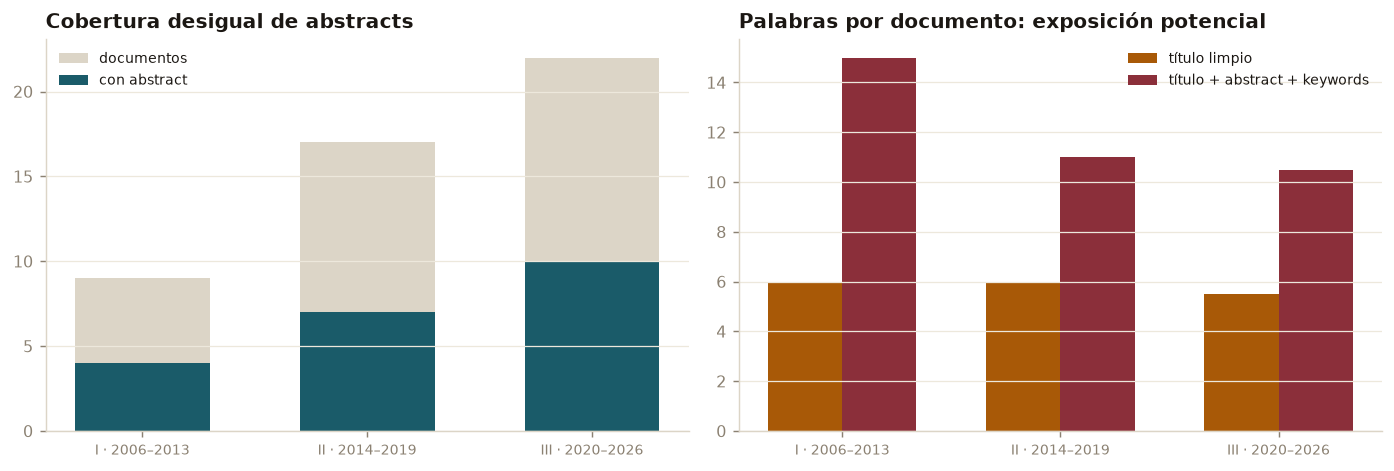

In [7]:
fm = pd.DataFrame(json.load(open(DATA/'frontmatter.json', encoding='utf-8')))
fm = fm.merge(corpus[['id','a1','periodo']], on='id', how='left')
fm['a1'] = fm['a1'].fillna(fm['anio']); fm['periodo'] = fm['periodo'].fillna(fm['a1'].map(periodo))

def limpiar_titulo(s):
    s = re.sub(r'^\s*(Discussion|Comment)\s*(?:on|of|:)?\s*', '', str(s), flags=re.I)
    s = re.sub(r'\([^)]*\)', ' ', s)
    for ch in ('«','»','“','”','"'): s = s.replace(ch,' ')
    return re.sub(r'\s+', ' ', s).strip()

VACIAS = set('''the of and to in for a an we this that is are be by as it its our from at on with
paper show shows study model models economy economic effect effects using use used result results
find finds new between when where which their they them than such both also more most can may
however into two these during through across over other under while each what how why there here
discussion discussions comment comments mimeo draft version forthcoming
de en el la los las un una unos unas y o que se su sus del al lo es son por con para sin sobre
como mas más este esta estos estas ser han hay entre cuando donde cual cuales muestra ello ella
tambien también otros otras cada desde hasta tras muy nos nuestra nuestro
'''.split())

fm['titulo_limpio'] = fm.titulo.fillna('').map(limpiar_titulo)
fm['texto_comparable'] = fm['titulo_limpio'].str.lower()
fm['tiene_abstract_real'] = fm.abstract.fillna('').str.strip().ne('')
fm['palabras_titulo'] = fm.titulo_limpio.str.split().str.len()
fm['palabras_ampliadas'] = (fm.titulo.fillna('') + ' ' + fm.abstract.fillna('') + ' ' +
                            fm.keywords.fillna('')).str.split().str.len()

periodos = ['I · 2006–2013', 'II · 2014–2019', 'III · 2020–2026']
colores = [PRACTICA, TEORIA, GAP]
coverage = fm.groupby('periodo').agg(documentos=('id','size'), abstracts=('tiene_abstract_real','sum'),
                                    mediana_titulo=('palabras_titulo','median'),
                                    mediana_ampliada=('palabras_ampliadas','median')).reindex(periodos)
display(coverage)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.8, 3.7))
x = np.arange(len(coverage))
ax1.bar(x, coverage.documentos, color=REGLA, width=.6, label='documentos')
ax1.bar(x, coverage.abstracts, color=TEORIA, width=.6, label='con abstract')
ax1.set_xticks(x); ax1.set_xticklabels(periodos, fontsize=8)
ax1.set_title('Cobertura desigual de abstracts'); ax1.legend(fontsize=8); ax1.grid(axis='x', visible=False)

ax2.bar(x-.17, coverage.mediana_titulo, width=.34, color=PRACTICA, label='título limpio')
ax2.bar(x+.17, coverage.mediana_ampliada, width=.34, color=GAP, label='título + abstract + keywords')
ax2.set_xticks(x); ax2.set_xticklabels(periodos, fontsize=8)
ax2.set_title('Palabras por documento: exposición potencial'); ax2.legend(fontsize=8)
ax2.grid(axis='x', visible=False)
plt.tight_layout(); guardar(fig, '04_cobertura_textual'); plt.show()


### 4.1 · Términos distintivos en títulos

El TF-IDF se calcula sobre los títulos limpios agregados por periodo. Así todos los documentos aportan la misma clase de evidencia. Con solo 48 documentos y tres periodos, el resultado es descriptivo y sensible a los cortes temporales.

→ figs/05_terminos_distintivos.png


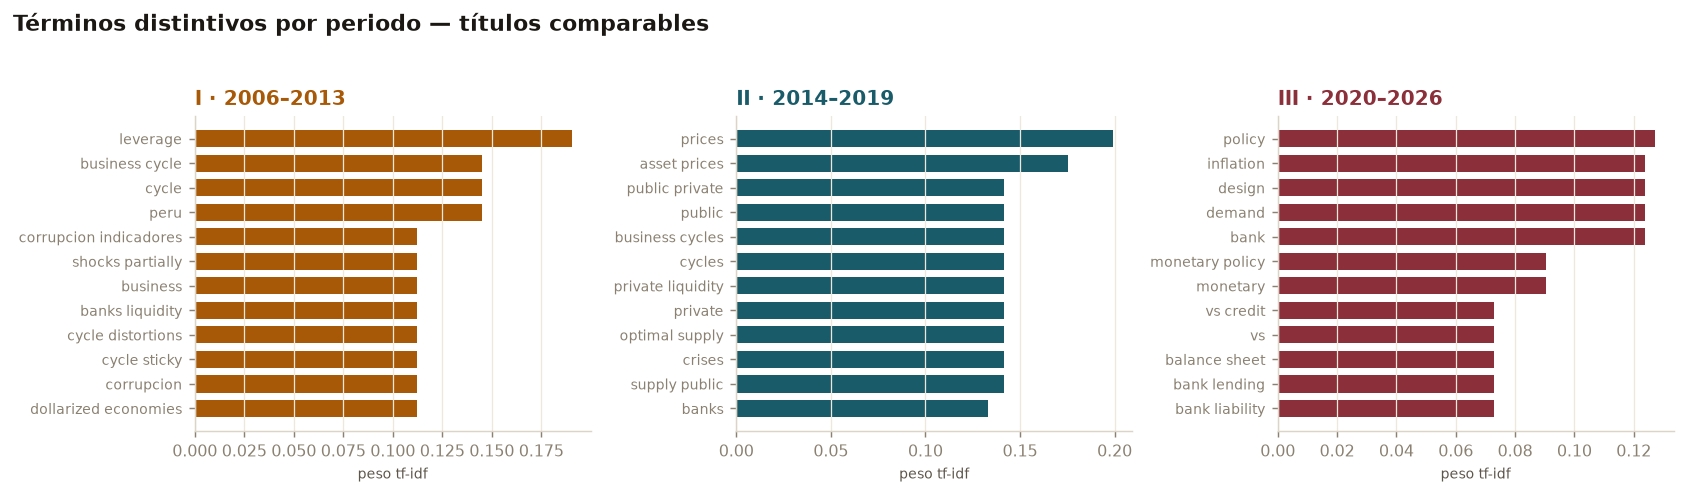

In [8]:
tv = TfidfVectorizer(ngram_range=(1,2), stop_words=list(VACIAS), sublinear_tf=True, strip_accents='unicode', max_df=1.0)
docs_p = [' '.join(fm[fm.periodo == p].texto_comparable) for p in periodos]
M = tv.fit_transform(docs_p); F = np.array(tv.get_feature_names_out())

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharex=False)
for ax, i, p, c in zip(axes, range(3), periodos, colores):
    row = M[i].toarray().ravel(); idx = row.argsort()[::-1][:12][::-1]
    ax.barh(range(len(idx)), row[idx], color=c, height=.7)
    ax.set_yticks(range(len(idx))); ax.set_yticklabels(F[idx], fontsize=8)
    ax.set_title(p, color=c); ax.grid(axis='y', visible=False)
    ax.set_xlabel('peso tf-idf', fontsize=8)
fig.suptitle('Términos distintivos por periodo — títulos comparables', x=.007, ha='left', y=1.04,
             fontsize=12, weight='bold')
plt.tight_layout(); guardar(fig, '05_terminos_distintivos'); plt.show()


## 5 · Red de co-palabras, como exploración

Dos términos se conectan si aparecen en el título de un mismo documento. Donthu et al. (2021) sitúan las redes de co-palabras dentro del *science mapping*, pero también recomiendan corpus mucho mayores. Con 48 documentos, la red sirve para formular hipótesis visuales, no para establecer la estructura estable de un campo. Se reporta la sensibilidad a cuatro combinaciones de umbrales.

,mín. documentos,mín. coocurrencias,nodos,aristas
0,2,2,19,27
1,3,2,13,15
2,3,3,6,3
3,4,4,2,1


componente mostrado: 17 términos · 26 aristas · 3 agrupamientos (una sola regla de comunidad)


→ figs/06_red_copalabras.png


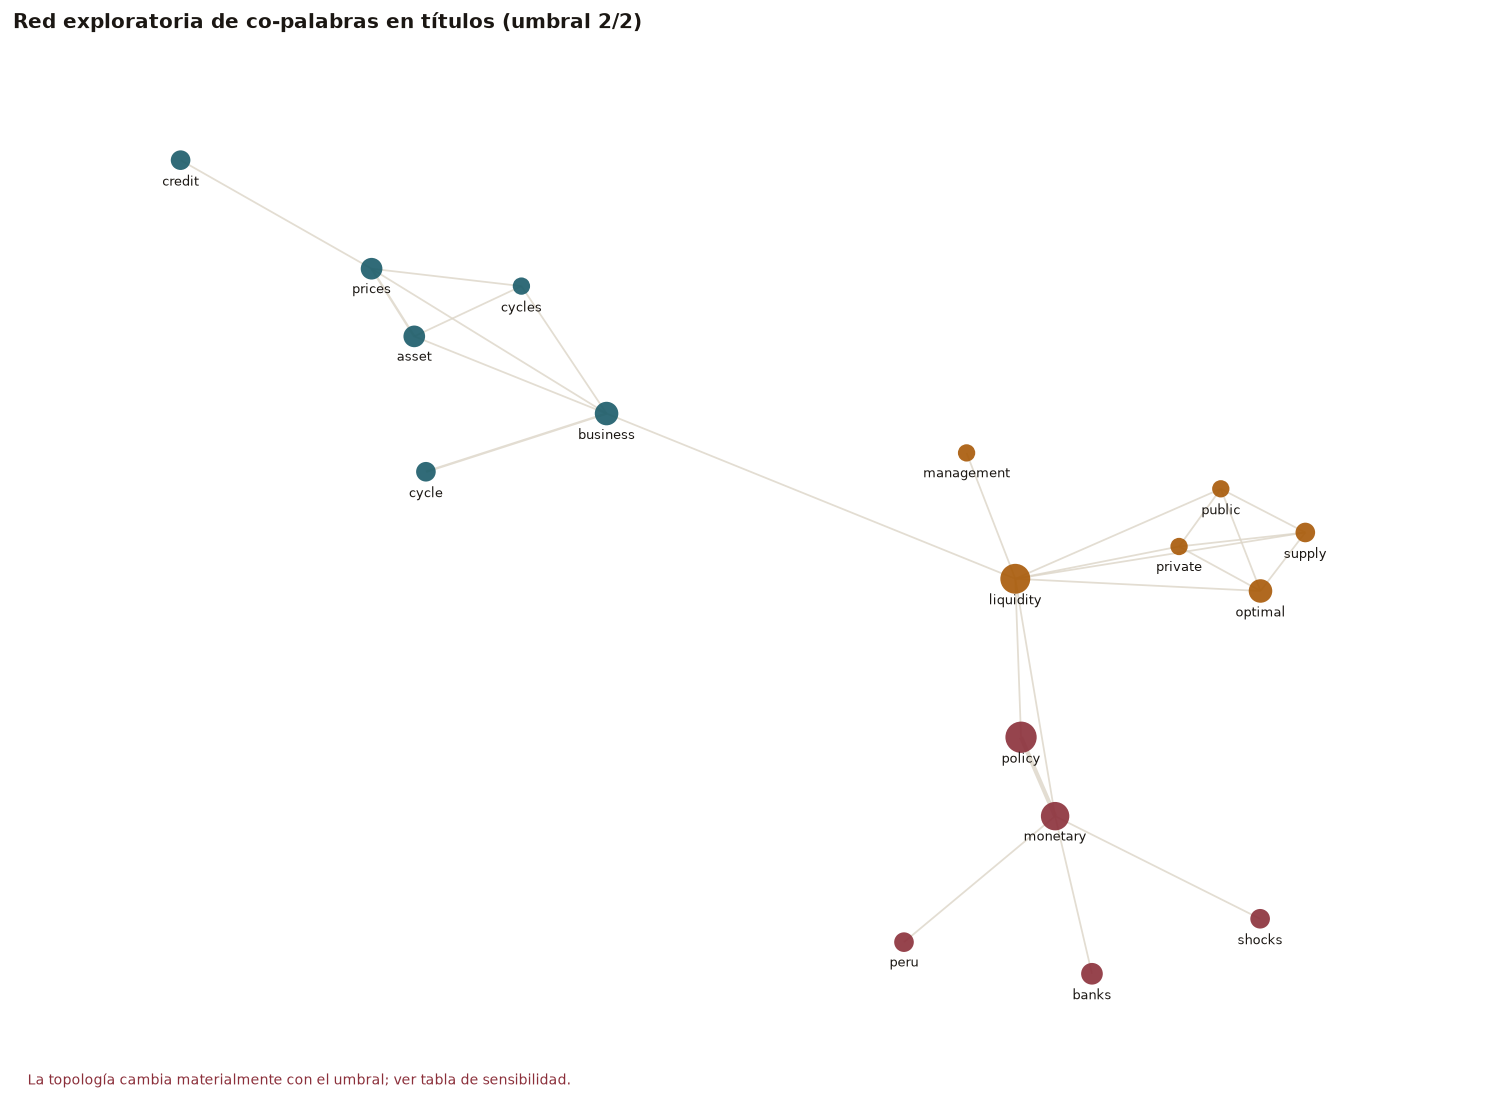

In [9]:
def red_copalabras(min_doc, min_co):
    cv = CountVectorizer(ngram_range=(1,1), min_df=min_doc, stop_words=list(VACIAS), strip_accents='unicode', binary=True)
    X = cv.fit_transform(fm.texto_comparable)
    V = np.array(cv.get_feature_names_out())
    CO = (X.T @ X).toarray(); np.fill_diagonal(CO, 0)
    freq = np.asarray(X.sum(0)).ravel()
    graph = nx.Graph()
    for i, term in enumerate(V): graph.add_node(term, freq=int(freq[i]))
    for i in range(len(V)):
        for j in range(i+1, len(V)):
            if CO[i, j] >= min_co: graph.add_edge(V[i], V[j], w=int(CO[i, j]))
    graph.remove_nodes_from([n for n, degree in graph.degree() if degree == 0])
    return graph

sens = []
for md, mc in [(2,2), (3,2), (3,3), (4,4)]:
    graph = red_copalabras(md, mc)
    sens.append({'mín. documentos':md, 'mín. coocurrencias':mc,
                 'nodos':graph.number_of_nodes(), 'aristas':graph.number_of_edges()})
display(pd.DataFrame(sens))

MIN_DOC, MIN_CO = 2, 2
G = red_copalabras(MIN_DOC, MIN_CO)
if G.number_of_nodes():
    G = G.subgraph(max(nx.connected_components(G), key=len)).copy()
com = list(nx.algorithms.community.greedy_modularity_communities(G, weight='w')) if G.number_of_edges() else [set(G)]
col = {n: SERIE[k % len(SERIE)] for k, community in enumerate(com) for n in community}
print(f'componente mostrado: {G.number_of_nodes()} términos · {G.number_of_edges()} aristas · '
      f'{len(com)} agrupamientos (una sola regla de comunidad)')

fig, ax = plt.subplots(figsize=(11.5, 8.6))
pos = nx.spring_layout(G, k=1.9/np.sqrt(max(G.number_of_nodes(),1)), seed=3,
                       weight='w', iterations=500)
nx.draw_networkx_edges(G, pos, ax=ax, edge_color=REGLA, alpha=.8,
                       width=[.3 + .34*G[u][v]['w'] for u, v in G.edges()])
nx.draw_networkx_nodes(G, pos, ax=ax, linewidths=0, alpha=.9,
                       node_size=[40 + 26*G.nodes[n]['freq'] for n in G],
                       node_color=[col[n] for n in G])
for n, (xp, yp) in pos.items():
    ax.text(xp, yp-.035, n, ha='center', va='top', fontsize=7.2, color=TINTA)
ax.set_title('Red exploratoria de co-palabras en títulos (umbral 2/2)')
ax.text(.01, .01, 'La topología cambia materialmente con el umbral; ver tabla de sensibilidad.',
        transform=ax.transAxes, fontsize=8, color=GAP)
ax.margins(.09); ax.axis('off')
plt.tight_layout(); guardar(fig, '06_red_copalabras'); plt.show()


## 6 · Mapa temático: códigos JEL declarados

Los códigos JEL son una taxonomía declarada por el autor, pero no todos los documentos la incluyen. El mapa se presenta como descripción del subconjunto con códigos y la conclusión sobre “etapas” se somete a un corte temporal alternativo.

periodo,I · 2006–2013,II · 2014–2019,III · 2020–2026
familia_es,,,
C · Métodos cuantitativos,1,0,0
D · Microeconomía,2,0,1
E · Macro y monetaria,4,7,7
F · Economía internacional,0,0,3
G · Economía financiera,3,6,4
H · Economía pública,1,0,0
O · Desarrollo y crecimiento,2,0,0


Familias presentes con corte alternativo:


periodo_alt
I · 2006–2012         D, H, O
II · 2013–2019        C, E, G
III · 2020–2026    D, E, F, G
Name: familia, dtype: str

→ figs/07_jel.png


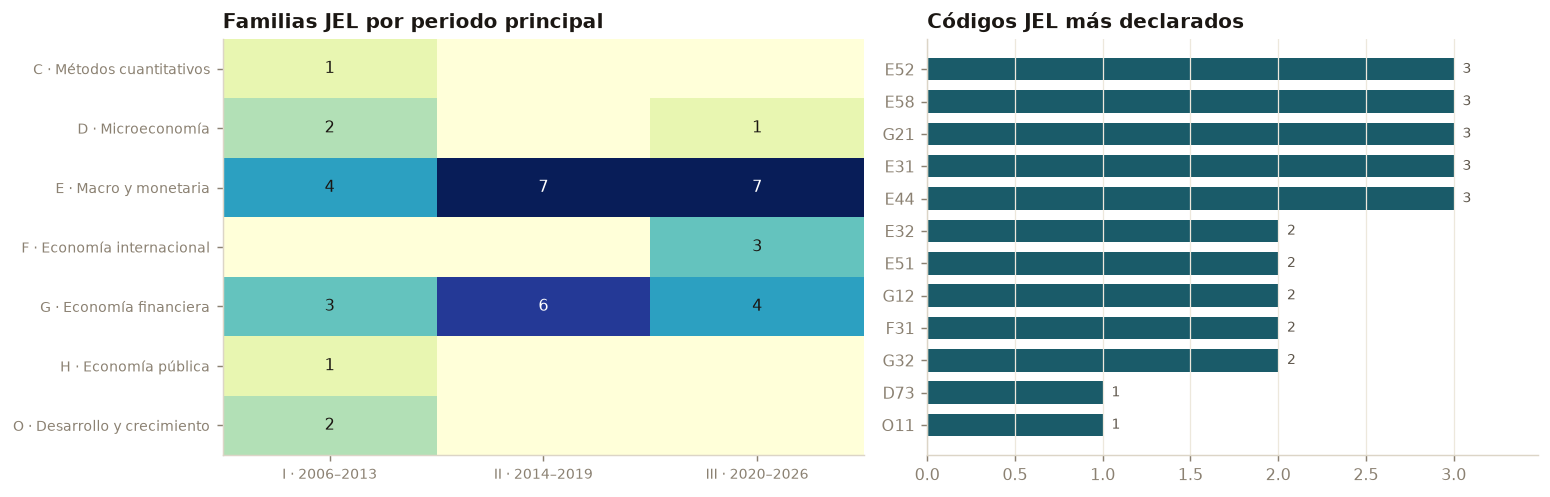

Lectura cauta: el predominio de E y G es robusto; la ubicación exacta de C, D, H y O cambia con el corte.


In [10]:
jel = []
for _, r in fm.iterrows():
    for j in (r['jel'] or []):
        jel.append({'id': r['id'], 'a1': r['a1'], 'periodo': r['periodo'], 'codigo': j, 'familia': j[0]})
J = pd.DataFrame(jel)
FAM = {'C':'C · Métodos cuantitativos','D':'D · Microeconomía','E':'E · Macro y monetaria',
       'F':'F · Economía internacional','G':'G · Economía financiera','H':'H · Economía pública',
       'O':'O · Desarrollo y crecimiento'}
J['familia_es'] = J.familia.map(FAM)
tab = J.pivot_table(index='familia_es', columns='periodo', values='id', aggfunc='count', fill_value=0)
tab = tab.reindex(columns=periodos, fill_value=0)
display(tab)

def periodo_alt(y):
    return 'I · 2006–2012' if y <= 2012 else ('II · 2013–2019' if y <= 2019 else 'III · 2020–2026')
J['periodo_alt'] = J.a1.map(periodo_alt)
alt = J.groupby('periodo_alt').familia.apply(lambda x: ', '.join(sorted(set(x))))
print('Familias presentes con corte alternativo:')
display(alt)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.9), gridspec_kw={'width_ratios':[1.05,1]})
ax1.imshow(tab.values, cmap='YlGnBu', aspect='auto')
ax1.set_xticks(range(len(tab.columns))); ax1.set_xticklabels(tab.columns, fontsize=8)
ax1.set_yticks(range(len(tab.index))); ax1.set_yticklabels(tab.index, fontsize=8)
for i in range(tab.shape[0]):
    for j in range(tab.shape[1]):
        v = tab.values[i, j]
        if v: ax1.text(j, i, int(v), ha='center', va='center', fontsize=9,
                       color='white' if v > tab.values.max()*.6 else TINTA)
ax1.set_title('Familias JEL por periodo principal'); ax1.grid(False)

cod = J.codigo.value_counts().head(12)
ax2.barh(cod.index[::-1], cod.values[::-1], color=TEORIA, height=.7)
for i, v in enumerate(cod.values[::-1]): ax2.text(v+.05, i, str(v), va='center', fontsize=8, color=SUAVE)
ax2.set_title('Códigos JEL más declarados'); ax2.grid(axis='y', visible=False)
ax2.set_xlim(0, cod.max()*1.16)
plt.tight_layout(); guardar(fig, '07_jel'); plt.show()
print('Lectura cauta: el predominio de E y G es robusto; la ubicación exacta de C, D, H y O cambia con el corte.')


## 7 · Red de coautoría

Son 24 artículos publicados y working papers. La red es una proyección de equipos: conecta a Bigio con cada coautor y a los coautores que firman juntos. El tamaño de cada coautor mide **cuántos trabajos comparte con Bigio**, no su grado ponderado dentro de toda la proyección.

31 coautores distintos · 52 vínculos en la proyección
coautores con más de un trabajo conjunto: {'Zilberman': 3, 'Bianchi': 3, 'Nuno': 3, 'Silva': 2}


→ figs/08_red_coautoria.png


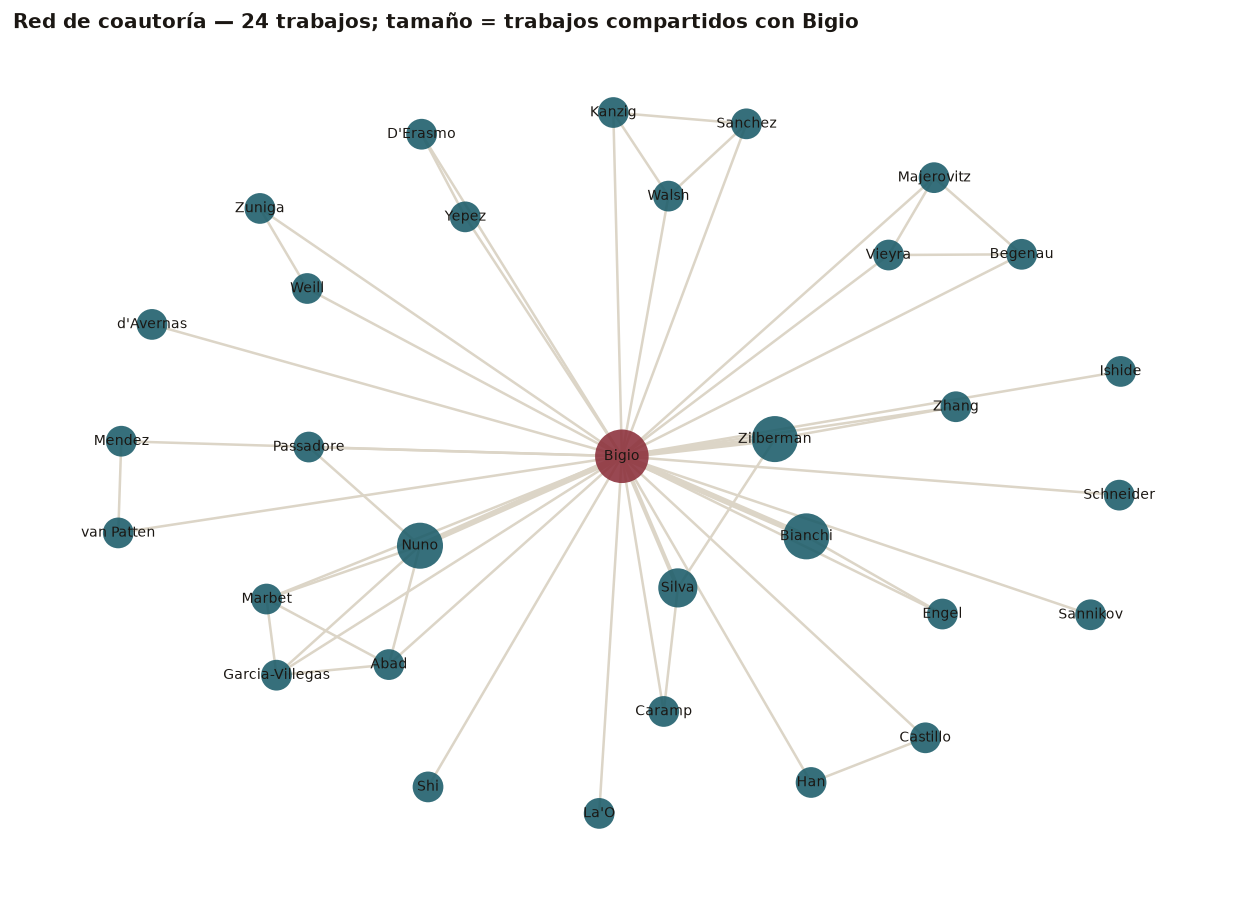

In [11]:
papers = corpus[corpus.genero.isin(['published','wp'])]
edges = []
joint_counts = Counter()
for _, r in papers.iterrows():
    if str(r.coautores) in ('—','nan',''): continue
    authors = list(dict.fromkeys(a.strip() for a in str(r.coautores).split(';') if a.strip()))
    for author in authors:
        edges.append(('Bigio', author)); joint_counts[author] += 1
    for i in range(len(authors)):
        for j in range(i+1, len(authors)): edges.append((authors[i], authors[j]))

Gc = nx.Graph()
for a, b in edges:
    Gc.add_edge(a, b, w=Gc.get_edge_data(a, b, {'w':0})['w'] + 1)
print(f'{len(joint_counts)} coautores distintos · {Gc.number_of_edges()} vínculos en la proyección')
print('coautores con más de un trabajo conjunto:',
      {k:v for k,v in joint_counts.most_common() if v > 1})

fig, ax = plt.subplots(figsize=(9.6, 7))
pos = nx.spring_layout(Gc, k=.78, seed=7, weight='w', iterations=300)
nx.draw_networkx_edges(Gc, pos, ax=ax, width=[.5+.9*d['w'] for *_, d in Gc.edges(data=True)],
                       edge_color=REGLA)
ns = [880 if n == 'Bigio' else 110+180*joint_counts[n] for n in Gc]
nc = [GAP if n == 'Bigio' else TEORIA for n in Gc]
nx.draw_networkx_nodes(Gc, pos, ax=ax, node_size=ns, node_color=nc, alpha=.88, linewidths=0)
nx.draw_networkx_labels(Gc, pos, ax=ax, font_size=8, font_color=TINTA)
ax.set_title('Red de coautoría — 24 trabajos; tamaño = trabajos compartidos con Bigio')
ax.axis('off')
plt.tight_layout(); guardar(fig, '08_red_coautoria'); plt.show()


,trabajos,coautores por trabajo,firmados solo
periodo,,,
I · 2006–2013,5,0.600,2
II · 2014–2019,8,1.625,0
III · 2020–2026,11,2.000,0


→ figs/09_colaboracion.png


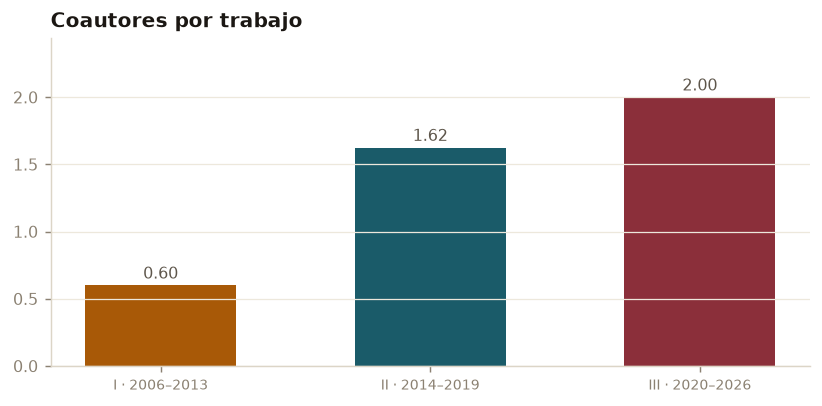

In [12]:
# ¿colabora más con el tiempo?
cc = corpus[corpus.genero.isin(['published','wp'])].copy()
cc['n_co'] = cc.coautores.apply(lambda s: 0 if str(s) in ('—','nan','') else len(str(s).split(';')))
g = cc.groupby('periodo').n_co.agg(['count','mean'])
g['solos'] = cc[cc.n_co == 0].groupby('periodo').size().reindex(g.index, fill_value=0)
display(g.rename(columns={'count':'trabajos','mean':'coautores por trabajo','solos':'firmados solo'}))

fig, ax = plt.subplots(figsize=(6.4, 3.2))
ax.bar(range(len(g)), g['mean'], color=[PRACTICA, TEORIA, GAP], width=.56)
for i, v in enumerate(g['mean']):
    ax.text(i, v+.05, f'{v:.2f}', ha='center', fontsize=9, color=SUAVE)
ax.set_xticks(range(len(g))); ax.set_xticklabels(g.index, fontsize=8)
ax.set_title('Coautores por trabajo'); ax.set_ylim(0, g['mean'].max()*1.22)
ax.grid(axis='x', visible=False)
plt.tight_layout(); guardar(fig, '09_colaboracion'); plt.show()


## 8 · Quién lo cita

875 trabajos citantes recuperados de Semantic Scholar para sus dieciocho trabajos más citados. Aquí no hay agregados prestados: cada fila es un paper con su revista, su año y su campo.

875 trabajos citantes únicos · 2009–2026


→ figs/10_quien_lo_cita.png


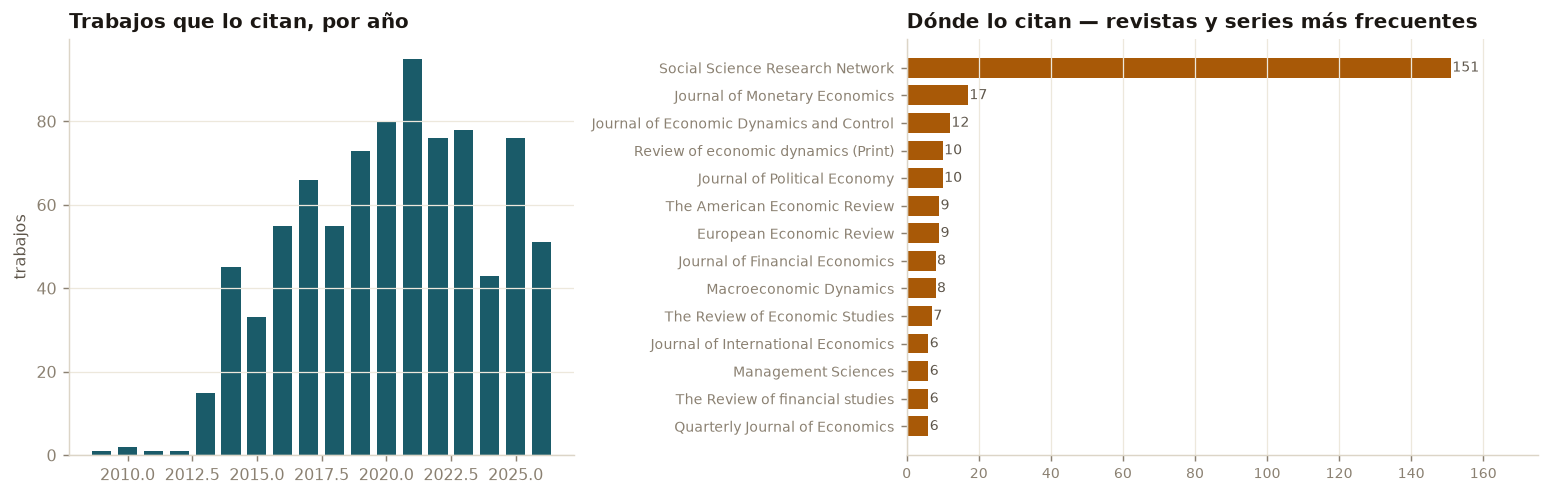

In [13]:
cit = json.load(open(DATA/'s2'/'s2_citations.json', encoding='utf-8'))
filas = []
for pid, lst in cit.items():
    for c in lst:
        if not c: continue
        filas.append({'citante': c.get('paperId'), 'titulo': c.get('title'), 'anio': c.get('year'),
                      'venue': (c.get('venue') or '').strip(),
                      'campos': ';'.join(c.get('fieldsOfStudy') or []),
                      'autores': ';'.join(a.get('name','') for a in (c.get('authors') or []))})
CT = pd.DataFrame(filas).drop_duplicates('citante')
print(f'{len(CT)} trabajos citantes únicos · {CT.anio.min():.0f}–{CT.anio.max():.0f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.9), gridspec_kw={'width_ratios':[1,1.25]})
sa = CT.dropna(subset=['anio']).groupby('anio').size()
sa = sa[sa.index >= 2009]
ax1.bar(sa.index, sa.values, color=TEORIA, width=.74)
ax1.set_title('Trabajos que lo citan, por año'); ax1.grid(axis='x', visible=False)
ax1.set_xlabel(''); ax1.set_ylabel('trabajos')

v = CT[CT.venue != ''].venue.value_counts().head(14)
ax2.barh(v.index[::-1], v.values[::-1], color=PRACTICA, height=.72)
for i, x in enumerate(v.values[::-1]):
    ax2.text(x+.4, i, str(x), va='center', fontsize=8, color=SUAVE)
ax2.set_title('Dónde lo citan — revistas y series más frecuentes')
ax2.tick_params(labelsize=7.5); ax2.grid(axis='y', visible=False); ax2.set_xlim(0, v.max()*1.16)
plt.tight_layout(); guardar(fig, '10_quien_lo_cita'); plt.show()


→ figs/11_autores_citantes.png


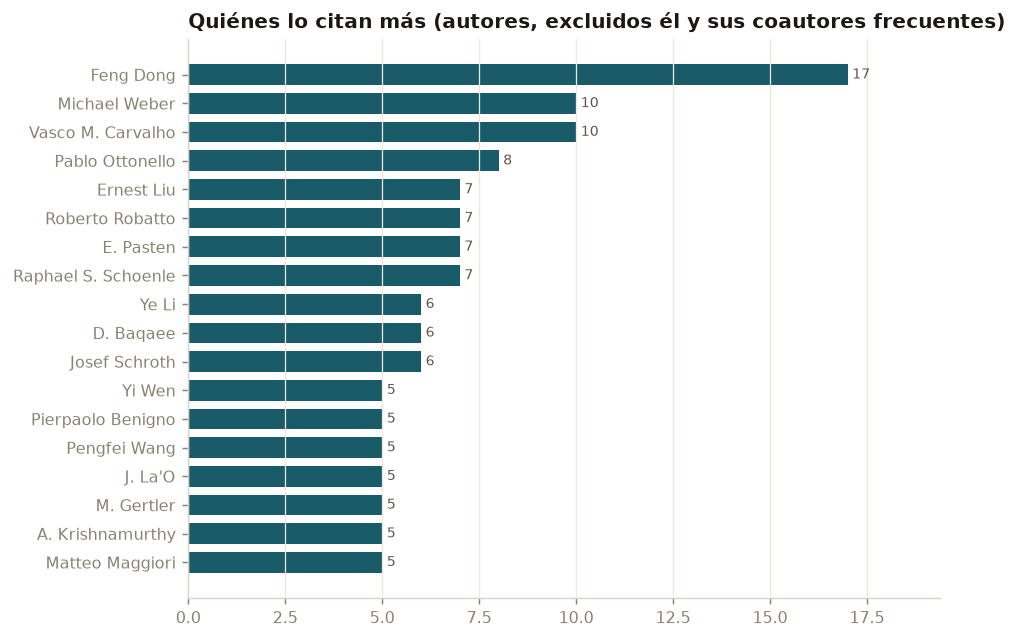

In [14]:
# los autores que más lo citan (excluyendo a él y sus coautores)
propios = {'Saki Bigio','Javier Bianchi','Galo Nuño','Eduardo Zilberman','Dejanir Silva'}
au = Counter(a for s in CT.autores for a in s.split(';') if a and a not in propios)
top_au = pd.Series(dict(au.most_common(18)))

fig, ax = plt.subplots(figsize=(7.4, 5))
ax.barh(top_au.index[::-1], top_au.values[::-1], color=TEORIA, height=.72)
for i, v in enumerate(top_au.values[::-1]):
    ax.text(v+.12, i, str(v), va='center', fontsize=8, color=SUAVE)
ax.set_title('Quiénes lo citan más (autores, excluidos él y sus coautores frecuentes)')
ax.grid(axis='y', visible=False); ax.set_xlim(0, top_au.max()*1.14)
plt.tight_layout(); guardar(fig, '11_autores_citantes'); plt.show()


## 9 · A quién cita: base candidata y control de calidad

La auditoría inicial encontró 83 referencias bien separadas entre 150 filas (55,3 %). Tras corregir el extractor se obtuvieron 1.413 entradas en 30 documentos. El control asistido sobre 100 filas nuevas registró 98 referencias bien separadas, 95 con apellido y año correctos, y 77 con título también utilizable. Los denominadores y poblaciones difieren entre rondas; no es una comparación pareada ni una validación humana externa. Las concordancias de conteo en ocho bibliografías no estiman exhaustividad.

La remediación local posterior deja 1.414 entradas, cuatro años ausentes por condición *forthcoming* y un solo título no aislado, omitido en el propio PDF. Los cien casos conocidos pasan la comprobación de regresión, pero esa cifra no estima precisión fuera de la muestra porque reutiliza los defectos que guiaron la corrección.

Precisamente, una muestra de reserva distinta, tomada con semilla 20260918 y excluyendo coincidencias literales con la muestra de desarrollo, obtuvo 97/100 referencias bien separadas, 95/100 con apellido y año correctos y 90/100 con título también utilizable. Su intervalo de Wilson al 95 % para fichas completas fue 82,6–94,5 %, por debajo del umbral operativo. Los diez defectos detectados fueron corregidos y pasan la regresión, pero ese 100/100 posterior vuelve a comprobar casos conocidos.

Una tercera muestra aleatoria no solapada, con semilla 20260919, obtuvo 100/100 segmentaciones correctas, 100/100 apellidos y años correctos y 98/100 títulos utilizables. El intervalo de Wilson al 95 % para fichas completas fue 93,0–99,4 %. Los dos defectos de frontera de título fueron corregidos y los cien casos pasan la regresión; la revisión sigue siendo asistida por Codex y no una auditoría humana externa.

El control técnico integral cubrió después las 1.435 filas. Combinó tamizaje determinista, los 300 controles previos y revisión visual asistida de todas las señales estructurales ampliadas. Documentó 18 operaciones estructurales, 19 filas netas añadidas y 17 correcciones de frontera de título. El estado final reúne 1.343 filas aceptadas, 90 corregidas y 2 excepciones atribuibles a la fuente. Quedan seis años sin valor numérico —cinco *forthcoming* y uno mal impreso como «219»— y un título que el PDF omite. La cobertura es integral en sentido técnico, pero no constituye una auditoría humana externa.

La consulta externa fue autorizada y cubrió las 1.435 filas mediante 1.267 consultas únicas, sin errores pendientes. La regla conservadora asignó alta confianza automática a 370 filas —303 identidades OpenAlex distintas— y dejó 24 para revisión. La adjudicación documental aceptó 19 como versiones de la misma obra y rechazó 5 como trabajos diferentes; una fila adicional se resolvió directamente por DOI. La capa separada contiene 390 filas resueltas —320 identidades distintas— y 1.045 filas sin identidad aceptada. En consecuencia, las redes de co-citación y acoplamiento bibliográfico exhaustivas permanecen pendientes.

1435 entradas candidatas · 30 documentos · estado: candidate_locally_enriched_identity_resolution_pending
Los títulos añadidos proceden de la cadena bibliográfica local; no equivalen a una identidad DOI/OpenAlex resuelta. Las consultas externas ya están completas; las identidades de alta confianza se conservan en una copia separada.
Regresión de defectos conocidos: 100/100 remediados; no es una nueva muestra.
Regresión del control de reserva: 100/100 casos remediados; tampoco es una nueva muestra.
Tercera muestra: 98/100 fichas utilizables antes de corregir; 100/100 casos pasan la regresión posterior.
Auditoría integral asistida: 1435 filas; 90 corregidas; 18 operaciones estructurales. No es certificación humana externa.


→ figs/12_referencias_calidad.png


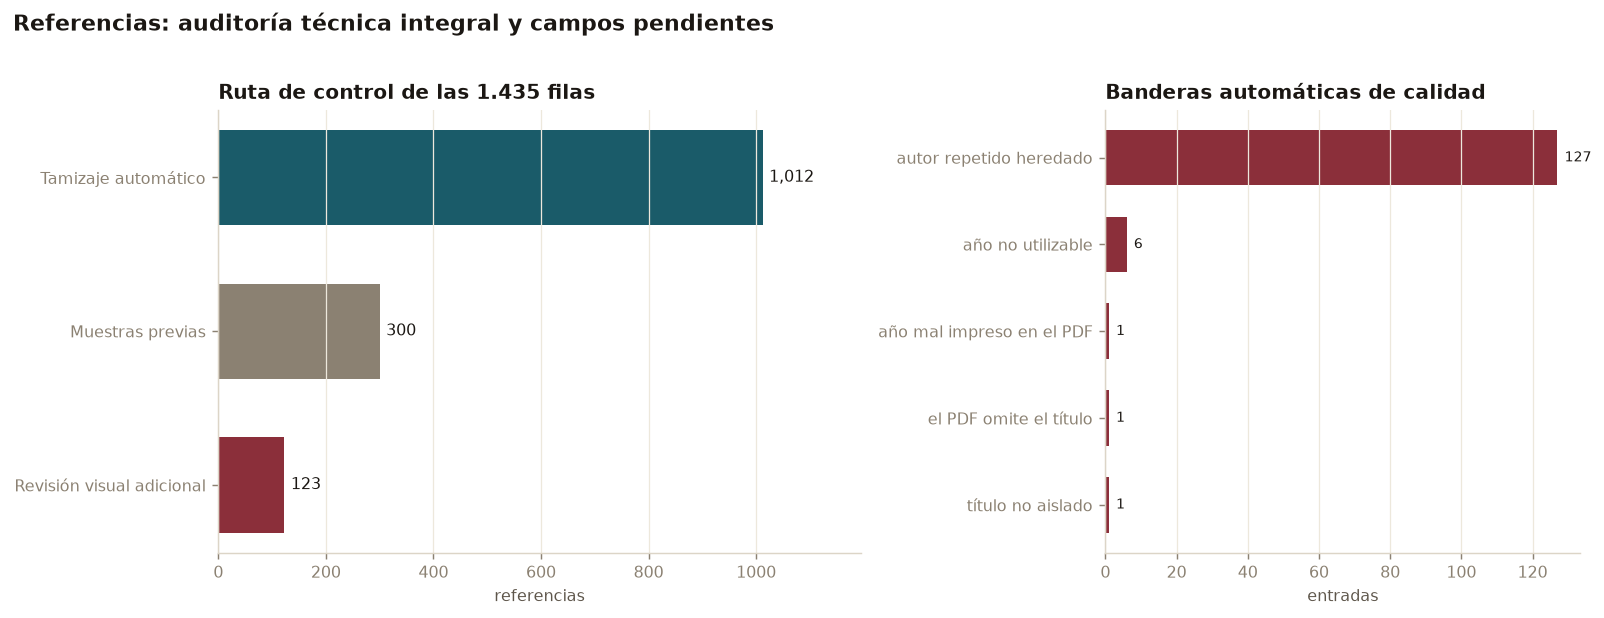

In [15]:
R = json.load(open(DATA/'referencias_parseadas_candidate.json', encoding='utf-8'))
refs = []
for doc_id, doc in R['documents'].items():
    for entry in doc['references']:
        refs.append({'doc':doc_id, 'apellido':entry['surname'], 'anio':entry['year'],
                     'flags':entry['quality_flags']})
RF = pd.DataFrame(refs)
meta_refs = R['meta']
print(f"{meta_refs['reference_entries']} entradas candidatas · "
      f"{meta_refs['documents_with_reference_section']} documentos · estado: {meta_refs['status']}")
print(meta_refs['warning'])

audit = json.load(open(DATA/'auditoria_referencias_control.json', encoding='utf-8'))
holdout = json.load(open(DATA/'auditoria_referencias_holdout.json', encoding='utf-8'))
remediation = json.load(open(DATA/'auditoria_referencias_remediacion.json', encoding='utf-8'))
holdout_remediation = json.load(open(DATA/'auditoria_referencias_holdout_remediacion.json', encoding='utf-8'))
third_audit = json.load(open(DATA/'auditoria_referencias_tercera_muestra.json', encoding='utf-8'))
third_remediation = json.load(open(DATA/'auditoria_referencias_tercera_muestra_remediacion.json', encoding='utf-8'))
integral_audit = json.load(open(DATA/'auditoria_integral_ia_referencias.json', encoding='utf-8'))
print(f"Regresión de defectos conocidos: {remediation['remediation_checks_passed']}/"
      f"{remediation['prior_sample_size']} remediados; no es una nueva muestra.")
print(f"Regresión del control de reserva: {holdout_remediation['remediation_checks_passed']}/100 "
      "casos remediados; tampoco es una nueva muestra.")
print(f"Tercera muestra: {third_audit['metrics']['record_ready']}/100 fichas utilizables antes de corregir; "
      f"{third_remediation['remediation_checks_passed']}/100 casos pasan la regresión posterior.")
print(f"Auditoría integral asistida: {integral_audit['meta']['population']} filas; "
      f"{integral_audit['meta']['audit_status_counts']['corrected']} corregidas; "
      f"{integral_audit['meta']['structural_operations']} operaciones estructurales. "
      "No es certificación humana externa.")
flag_counts = pd.Series(meta_refs['quality_flag_counts']).rename(index={
    'inherited_author_notation':'autor repetido heredado',
    'missing_year':'año no utilizable',
    'source_omits_title':'el PDF omite el título',
    'title_not_isolated':'título no aislado',
    'source_year_malformed':'año mal impreso en el PDF',
}).sort_values()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.4, 4.6), gridspec_kw={'width_ratios':[1.15,.85]})
route_counts = integral_audit['meta']['audit_route_counts']
labels = ['Tamizaje automático', 'Muestras previas', 'Revisión visual adicional']
values = [route_counts['automatic_screen_pass'], route_counts['prior_manual_sample'],
          route_counts['exhaustive_visual_multiwork_pattern_accepted'] +
          route_counts['exhaustive_visual_correction'] +
          route_counts['exhaustive_visual_exception_accepted']]
ax1.barh(labels[::-1], values[::-1], color=[GAP, TENUE, TEORIA], height=.62)
for i, value in enumerate(values[::-1]): ax1.text(value+12, i, f'{value:,}', va='center', fontsize=9)
ax1.set_xlim(0, max(values)*1.18)
ax1.set_title('Ruta de control de las 1.435 filas')
ax1.set_xlabel('referencias'); ax1.grid(axis='y', visible=False)

ax2.barh(flag_counts.index, flag_counts.values, color=GAP, height=.64)
for i, v in enumerate(flag_counts.values): ax2.text(v+2, i, str(v), va='center', fontsize=8)
ax2.set_title('Banderas automáticas de calidad')
ax2.set_xlabel('entradas'); ax2.grid(axis='y', visible=False)
fig.suptitle('Referencias: auditoría técnica integral y campos pendientes', x=.01, ha='left', y=1.02,
             fontsize=12, weight='bold')
plt.tight_layout(); guardar(fig, '12_referencias_calidad'); plt.show()


### 9.1 · Prueba acotada de anclas doctrinales

La búsqueda de 32 nombres en los 3,38 millones de caracteres del corpus permite documentar presencia o ausencia **explícita**. La ausencia de Gurley, Shaw o la *Banking School* sostiene únicamente esta formulación: no se observa una genealogía histórica explícita hacia esas tradiciones. No permite concluir que Bigio llegó a sus ideas con independencia cognitiva ni falsificar toda posible influencia indirecta.

→ figs/13_anclas_doctrinales.png


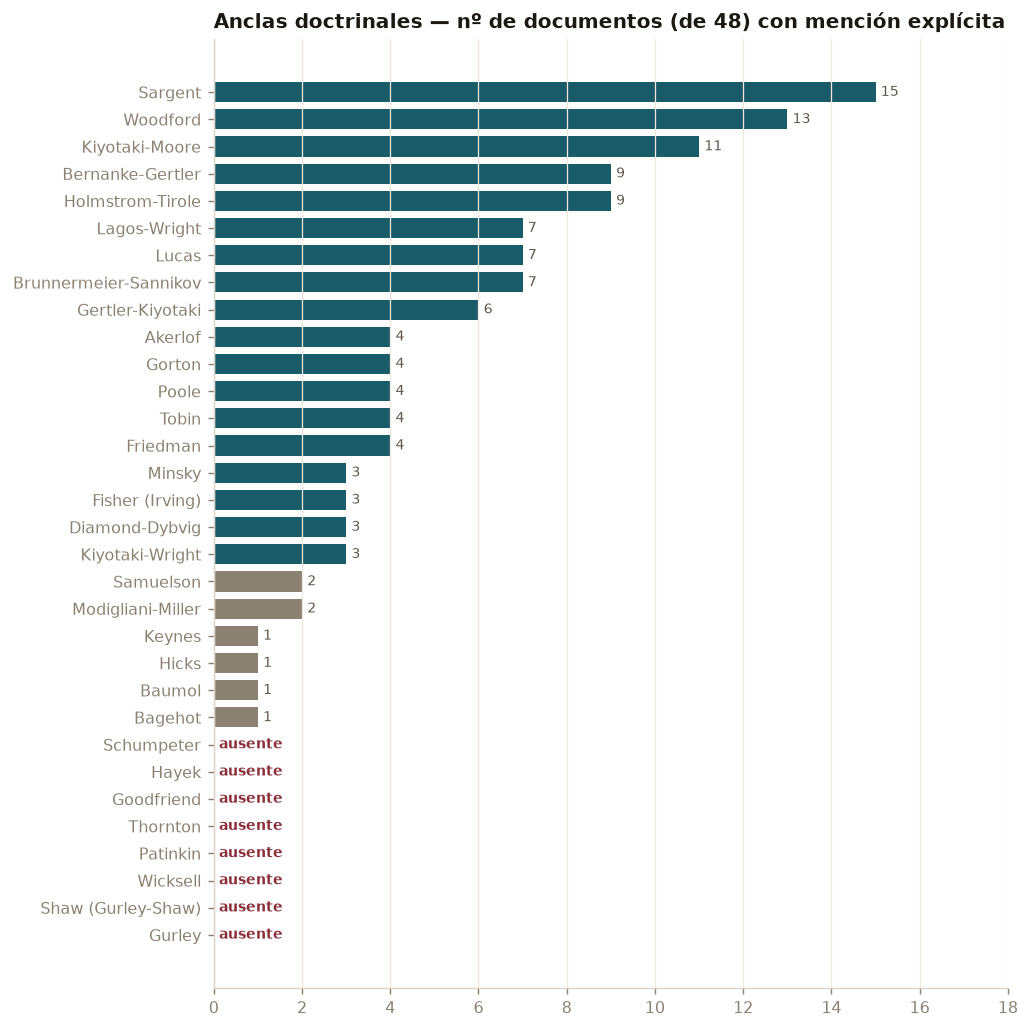

Sin mención explícita: Gurley, Shaw (Gurley-Shaw), Wicksell, Patinkin, Thornton, Goodfriend, Hayek, Schumpeter


In [16]:
anc = json.load(open(DATA/'anclas_doctrinales.json', encoding='utf-8'))
A = pd.Series({k: len(v) for k, v in anc.items()}).sort_values()
colores_a = [GAP if v == 0 else (TENUE if v <= 2 else TEORIA) for v in A.values]

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(A.index, A.values, color=colores_a, height=.74)
for i, v in enumerate(A.values):
    ax.text(v+.12, i, 'ausente' if v == 0 else str(v), va='center', fontsize=8,
            color=GAP if v == 0 else SUAVE, weight='bold' if v == 0 else 'normal')
ax.set_title('Anclas doctrinales — nº de documentos (de 48) con mención explícita')
ax.set_xlim(0, A.max()*1.2); ax.grid(axis='y', visible=False)
ax.axvline(0, color=GAP, lw=1)
plt.tight_layout(); guardar(fig, '13_anclas_doctrinales'); plt.show()

print('Sin mención explícita:', ', '.join(A[A == 0].index))


## 10 · Índice de figuras generadas

In [17]:
for f in sorted(FIGS.glob('*.png')):
    print(f'{f.name:34} {f.stat().st_size/1024:7.0f} KB')


01_corpus.png                          110 KB
02_impacto.png                         142 KB
03_rezago.png                          140 KB
04_cobertura_textual.png                54 KB
05_terminos_distintivos.png            124 KB
06_red_copalabras.png                  138 KB
07_jel.png                              82 KB
08_red_coautoria.png                   284 KB
09_colaboracion.png                     24 KB
10_quien_lo_cita.png                   117 KB
11_autores_citantes.png                 85 KB
12_referencias_calidad.png              87 KB
13_anclas_doctrinales.png              145 KB


---

## Límites declarados

1. **Unidad textual.** La cobertura de abstracts es desigual. Las comparaciones de términos y co-palabras usan solo títulos limpios; pierden detalle, pero hacen comparable el aporte de cada documento.
2. **Tamaño del corpus.** Cuarenta y ocho documentos son pocos para *science mapping*. La red de co-palabras es exploratoria y su topología cambia con los umbrales.
3. **Periodización.** El corte 2013/2014 desplaza familias JEL entre etapas. Solo el predominio agregado de macroeconomía monetaria y finanzas es robusto a la prueba presentada.
4. **Referencias salientes.** La muestra de reserva registró 90/100 fichas completas; una tercera muestra no solapada registró 100/100 filas bien separadas, 100/100 con apellido y año correctos y 98/100 fichas completas, con intervalo de Wilson al 95 % de 93,0–99,4 % para este último indicador. El control técnico integral posterior cubrió las 1.435 filas, documentó 18 operaciones estructurales, añadió 19 filas netas y corrigió 17 fronteras de título. Quedan un título omitido por la fuente y seis años sin valor numérico, uno por impresión malformada. OpenAlex respondió para todas las filas: 370 alcanzaron alta confianza automática; de las 24 coincidencias provisionales, la auditoría documental aceptó 19 y rechazó 5. Una fila adicional se resolvió directamente por DOI. La capa adjudicada reúne 390 filas resueltas —320 identidades distintas— y deja 1.045 sin identidad aceptada. `referencias_parseadas_candidate.json` permanece sin habilitación para redes exhaustivas o porcentajes históricos porque la capa identificada no es completa y el control integral fue asistido por Codex, no ejecutado por un auditor humano externo independiente. Semantic Scholar solo devuelve referencias para 4 de 61 trabajos consultados.
5. **Citas entrantes.** OpenAlex separa versiones de la misma obra. Se agruparon 75 registros de investigación en 34 obras y no se suman sus `cited_by_count`; la serie de impacto es una aproximación conservadora de versiones representativas. Las facetas institucionales son de pertenencia múltiple y no son aditivas.
6. **Fechas de primera versión.** Siete de trece fechas de artículos publicados tienen evidencia alta y seis confianza media. El rezago promedio de 4,8 años se interpreta con esa incertidumbre.
7. **Anclas doctrinales.** Una ausencia de nombres demuestra falta de genealogía explícita en el corpus, no independencia intelectual ni ausencia de canales indirectos.
8. **Actualización.** OpenAlex y Semantic Scholar son fotografías fechadas y sus conteos cambian con el tiempo.
